# Session 2 — Reciprocal mapping: spinal cord ↔ mouse whole brain

**Lipari Genomics Workshop 2026 — Interactive Part 2B (Map to whole brain)**

In Session 1 you built a spinal-cord (SpC) cell-type taxonomy. Here you will
relate it to the **Allen mouse whole-brain (AIT21)** atlas with a *reciprocal*
mapping, then ask **where in the mouse brain** the spinal-like cell types live by
projecting onto the ABC mouse-brain **MERFISH spatial atlas**.

First we **meet the dataset** — the ABC mouse-brain MERFISH spatial atlas and its
own cell-type taxonomy. Then the mapping:

1. **Forward** — map our SpC cells onto mouse-WB **subclasses**: *which
   whole-brain cell types did our spinal cord capture?*
2. **Reverse** — map mouse-WB subclasses onto **our Session-1 (V2) spinal cord**:
   *which whole-brain types resemble a spinal type?*
3. **Reciprocal** — keep the pairs that agree **both** ways.
4. **Spatial** — paint the detected / reciprocal subclasses back onto the brain.

> All seeds are fixed, and the heavy mapping was run once by the `processing/`
> scripts — here we just **load and explore** the results.

## 0. Setup

Import libraries, **fix all random seeds**, and point at the pre-computed
artifacts in `/results/` (built by `processing/01`–`04`) and the bundled MERFISH
spatial atlas. `mapping_io.py` carries the reciprocal-mapping helpers.

In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 0
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
sc.settings.seed = SEED
sc.settings.verbosity = 1

# Reciprocal-mapping helpers live with the Session-2 processing scripts.
PROC_DIR = '/code/lipari_genomics_workshop_2026/session2/processing'
sys.path.insert(0, PROC_DIR)
import mapping_io as mio

# --- Inputs (built by processing/01-04; do not regenerate live) ----------------
QUERY_H5AD      = '/results/SpC_workshop_snRNA.h5ad'                 # Session-1 query
FORWARD_JSON    = '/results/SpC_workshop_WB_SUBCLASS_MAPPING/hann_results.json'
REVERSE_JSON    = '/results/WB_SUBCLASS_to_SpC_MAPPING/hann_results.json'
RECIPROCAL_CSV  = '/results/reciprocal_best_hits.csv'
SUBCLASS_OVERLAP_CSV   = '/results/reciprocal_subclass_overlap.csv'   # OC reciprocity (subclass)
SUPERTYPE_RECIP_CSV    = '/results/reciprocal_supertype_hits.csv'     # OC reciprocity (supertype)
SUBSAMPLED_ABC_H5AD    = '/results/wb_subsampled_ABC.h5ad'            # student-sized mouse-WB snRNA
SPATIAL_ATLAS   = ('/data/mouse_wb_spatial_tutorial/reference/spatial_atlas/'
                   'C57BL6J-638850-16good-sections-raw-meta.h5ad')

WB_SUBCLASS_LEVEL = 'subclass_label'   # forward result level (mouse WB)
ATLAS_SUBCLASS    = 'subclass'         # atlas .obs column
ATLAS_SUPERTYPE   = 'supertype'        # atlas .obs column (finer level)
QUERY_SUBCLASS    = 'Subclass_V2'      # our spinal subclass label
QUERY_GROUP       = 'Group_V2'         # our spinal group label
OVERLAP_MIN       = 0.50               # min Wilson-lower-bound overlap for "reciprocal"
MIN_PROB          = 0.50               # min bootstrapping probability to keep a mapping
SUPERTYPE_REVERSE_JSON = '/results/WB_SUPERTYPE_to_SpC_MAPPING/hann_results.json'

for p in [QUERY_H5AD, FORWARD_JSON, REVERSE_JSON, RECIPROCAL_CSV,
          SUBCLASS_OVERLAP_CSV, SUPERTYPE_RECIP_CSV, SUPERTYPE_REVERSE_JSON,
          SPATIAL_ATLAS]:
    print(f"{'OK ' if os.path.exists(p) else 'MISSING'} {p}")

OK  /results/SpC_workshop_snRNA.h5ad
OK  /results/SpC_workshop_WB_SUBCLASS_MAPPING/hann_results.json
OK  /results/WB_SUBCLASS_to_SpC_MAPPING/hann_results.json
OK  /results/reciprocal_best_hits.csv
OK  /results/reciprocal_subclass_overlap.csv
OK  /results/reciprocal_supertype_hits.csv
OK  /results/WB_SUPERTYPE_to_SpC_MAPPING/hann_results.json
OK  /data/mouse_wb_spatial_tutorial/reference/spatial_atlas/C57BL6J-638850-16good-sections-raw-meta.h5ad


## 1. The dataset — the mouse whole-brain MERFISH atlas

Before any mapping, meet the spatial dataset we will project onto: the ABC
mouse-brain **MERFISH** atlas (16 clean sections, ~1.2 M cells; each cell carries
its mouse-WB **subclass** / **supertype** and a CCF region). This is our reference
canvas — the rest of the notebook asks *which parts of this brain look like spinal
cord*. `build_spatial_reference` also returns each subclass's **spatial
specificity** (1 − fraction of sections it appears in) so we can down-weight
ubiquitous types later.

In [2]:
adata_atlas, specificity = mio.build_spatial_reference(
    SPATIAL_ATLAS, subclass_key=ATLAS_SUBCLASS)
print(adata_atlas.shape)
print('\nMost spatially specific subclasses:')
print(specificity.sort_values(ascending=False).head(8))

(1215217, 550)

Most spatially specific subclasses:
subclass
298 PRP Gata3 Slc6a5 Gly-Gaba    0.9375
292 MV Nkx6-1 Gly-Gaba           0.9375
295 CBN Dmbx1 Gaba               0.9375
096 PVHd Gsc Gaba                0.9375
259 MDRNd Bves Glut              0.9375
262 Pineal Crx Glut              0.9375
260 MDRNv Crp Glut               0.9375
280 NLL-po Pax7 Gaba             0.9375
Name: spatial_specificity, dtype: float64


### Lay the sections out on a grid

The 16 MERFISH sections overlap in raw coordinates; tile them into a montage so
we can view the whole brain at once. (Helper adapted from the spatial tutorial.)

In [3]:
def tile_sections_on_grid(adata, section_key='brain_section_label',
                          spatial_key='spatial_grid', pad=0.0, new_key='spatial_tiled'):
    coords = np.asarray(adata.obsm[spatial_key])
    if isinstance(adata.obs[section_key].dtype, pd.CategoricalDtype):
        sections = list(adata.obs[section_key].cat.categories)
    else:
        sections = list(pd.unique(adata.obs[section_key]))
    centers, widths, heights = {}, [], []
    for s in sections:
        m = (adata.obs[section_key].values == s); sc_ = coords[m]
        if sc_.size == 0:
            centers[s] = np.array([0., 0.]); widths.append(0.); heights.append(0.); continue
        cmin, cmax = sc_.min(0), sc_.max(0)
        widths.append(cmax[0]-cmin[0]); heights.append(cmax[1]-cmin[1]); centers[s] = sc_.mean(0)
    tile_w = (max(widths) if widths else 0.) + pad
    tile_h = (max(heights) if heights else 0.) + pad
    n_cols = int(np.ceil(np.sqrt(len(sections))))
    new = coords.copy()
    for i, s in enumerate(sections):
        r, c = i // n_cols, i % n_cols
        m = (adata.obs[section_key].values == s)
        new[m] = coords[m] + (np.array([c*tile_w, r*tile_h], float) - centers[s])
    adata.obsm[new_key] = new


def plot_section(xx, yy, cc=None, val=None, cmap=None, s=0.5, alpha=1.0,
                 fig_width=12, fig_height=12, title=None):
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    if cmap is not None:
        sct = ax.scatter(xx, yy, s=s, c=val, marker='.', cmap=cmap, alpha=alpha)
    else:
        sct = ax.scatter(xx, yy, s=s, color=cc, marker='.', alpha=alpha)
    ax.axis('equal'); ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title)
    return fig, ax, sct

tile_sections_on_grid(adata_atlas, pad=0.0)
adata_atlas.obsm['spatial_tiled'][:, 1] *= -1            # flip y so the brain is upright
adata_atlas.obs['x'] = adata_atlas.obsm['spatial_tiled'][:, 0]
adata_atlas.obs['y'] = adata_atlas.obsm['spatial_tiled'][:, 1]
print('tiled', adata_atlas.n_obs, 'cells across',
      adata_atlas.obs['brain_section_label'].nunique(), 'sections')

tiled 1215217 cells across 16 sections


## 1b. Reference cell-type identities in space (neurons)

Here is the atlas's **own** taxonomy in space — our starting point, **before** any
cross-species mapping. We show **neurons only** (drop the ubiquitous `… NN`
non-neuronal subclasses, which blanket the entire brain) so neuronal structure is
visible. Each cell is drawn in the atlas's *own* colour for that level — first
**subclass**, then the finer **supertype**.

In [4]:
def plot_identities(obs, color_col, label_col, title, n_legend=18, s=0.25):
    """Montage coloured by an atlas annotation's own per-cell *_color column,
    with a legend of the most common identities."""
    import matplotlib.patches as mpatches
    fig, ax, _ = plot_section(obs['x'], obs['y'], cc=obs[color_col].values, s=s,
                              title=title)
    top = obs[label_col].astype(str).value_counts().head(n_legend).index
    cmap = dict(zip(obs[label_col].astype(str), obs[color_col].astype(str)))
    ax.legend(handles=[mpatches.Patch(color=cmap[v], label=v) for v in top],
              bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, frameon=False)
    plt.show()

neuron_obs = adata_atlas.obs[
    ~adata_atlas.obs[ATLAS_SUBCLASS].str.contains(' NN$', regex=True)].copy()
print(neuron_obs.shape[0], 'neuronal cells;',
      neuron_obs['subclass'].nunique(), 'subclasses,',
      neuron_obs['supertype'].nunique(), 'supertypes')

684705 neuronal cells; 314 subclasses, 1147 supertypes


### Neuron **subclasses** (atlas colours)

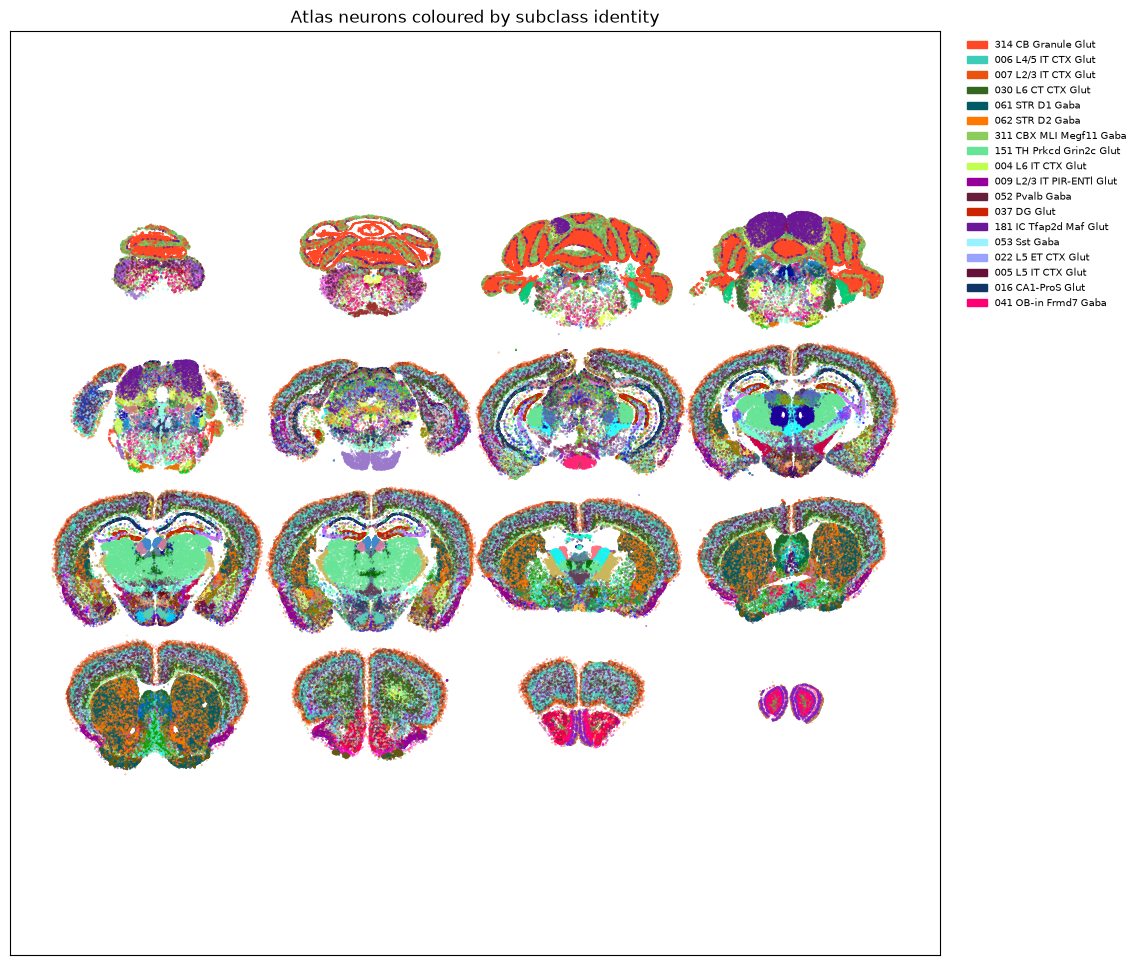

In [5]:
plot_identities(neuron_obs, 'subclass_color', 'subclass',
                'Atlas neurons coloured by subclass identity')

### Neuron **supertypes** (atlas colours)

Supertype is the next finer level below subclass — many more categories, so the
legend shows only the most abundant ones, but every cell is coloured.

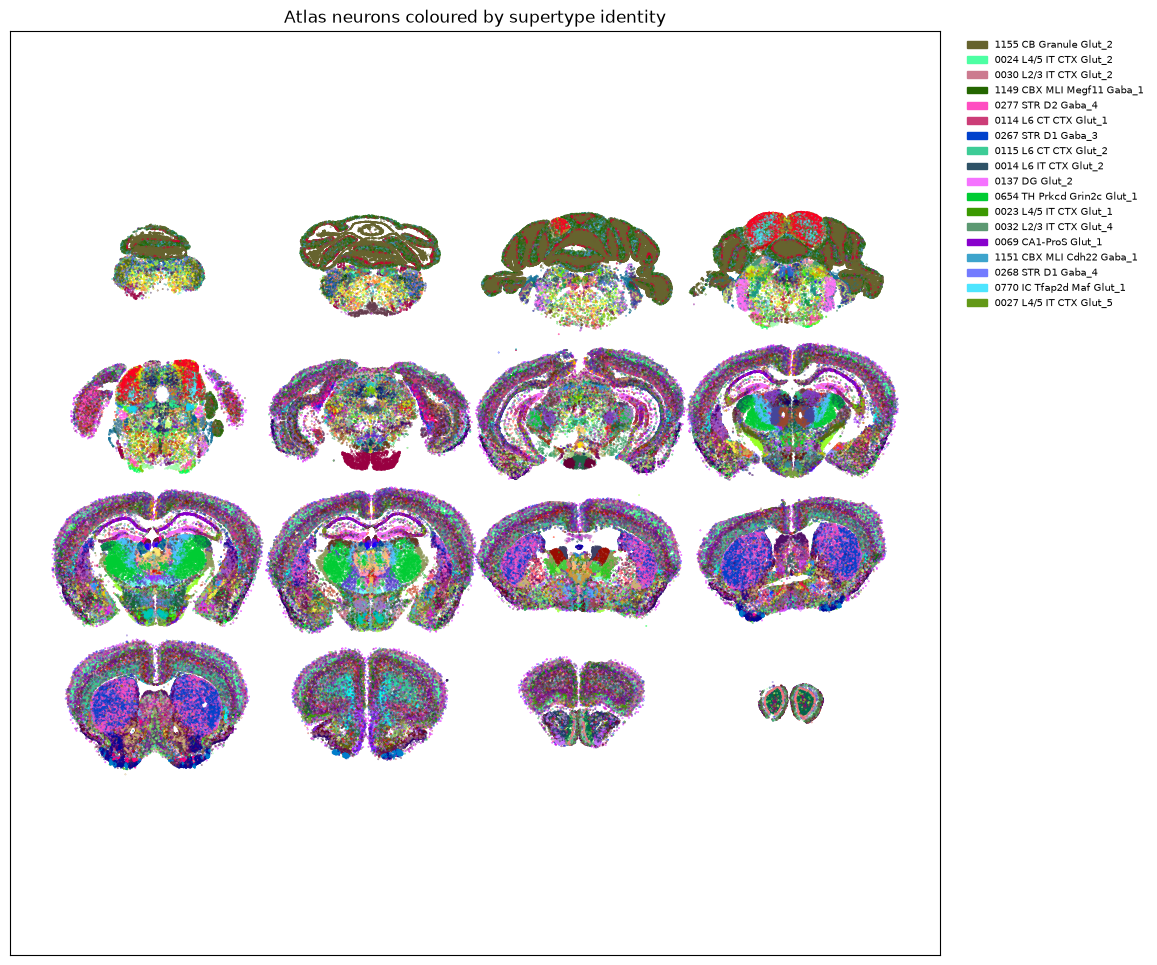

In [6]:
plot_identities(neuron_obs, 'supertype_color', 'supertype',
                'Atlas neurons coloured by supertype identity')

## 2. Forward — which mouse whole-brain types did we capture?

`cell_type_mapper` (the MapMyCells engine) assigned every spinal-cord nucleus to
its best-matching mouse-WB **subclass**. We load that result and attach the
spinal cells' own `Subclass_V2` / `Group_V2` labels so we can compare.

In [7]:
mapping_df = mio.load_mapping_results(FORWARD_JSON, levels=[WB_SUBCLASS_LEVEL])
print(mapping_df.shape[0], 'spinal cells mapped to a mouse-WB subclass')

# Attach our spinal labels (read obs only; backed='r' keeps it light).
adata_q = sc.read_h5ad(QUERY_H5AD, backed='r')
qobs = adata_q.obs[[QUERY_SUBCLASS, QUERY_GROUP]].copy()
mapping_df = mapping_df.join(qobs, how='left')

# Canonical spinal-cord V2 colour palettes (label -> hex) straight from the atlas
# h5ad `uns`, so every Subclass_V2 / Group_V2 plot uses the SAME colours as
# Session 1. `uns['<key>_colors']` is aligned to the category order of obs['<key>'].
def load_palette(adata, key):
    cats = adata.obs[key].astype('category').cat.categories
    cols = list(adata.uns[f'{key}_colors'])
    return {c: cols[i] for i, c in enumerate(cats) if i < len(cols)}

SUBCLASS_PAL = load_palette(adata_q, QUERY_SUBCLASS)   # Subclass_V2 colours
GROUP_PAL = load_palette(adata_q, QUERY_GROUP)         # Group_V2 colours
print(f'loaded {len(SUBCLASS_PAL)} Subclass_V2 + {len(GROUP_PAL)} Group_V2 colours')
mapping_df.head()

58507 spinal cells mapped to a mouse-WB subclass
loaded 18 Subclass_V2 + 111 Group_V2 colours


,subclass_label,subclass_label_prob,subclass_label_corr,subclass_label_runner_up,Subclass_V2,Group_V2
cell_id,,,,,,
AAACATGCACAAAGAC-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,245 SPVI-SPVC Tlx3 Ebf3 Glut,0.85,0.515553,258 SPVC Nmu Glut,Glut-D,Sp2-3 TAC3 NMU Glut
AAACCGAAGCACCACA-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,317 Astro-CB NN,0.65,0.367570,321 Astroependymal NN,Astro,NN GFAP WM-Astro
AAACGCGCAAGCGAGC-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,277 DTN-LDT-IPN Otp Pax3 Gaba,0.36,0.261489,279 PSV Pax2 Gly-Gaba,NaN,NaN
AAAGCGGGTCCAAGAC-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,326 OPC NN,0.95,0.228419,327 Oligo NN,Vascular,NN CLDN5 Endo
AAATCCGGTGGTTCTT-L8XR_211007_02_E04-3fbdabceb6735c734cd17b28c2ef9b96fa7dc692,306 SPVI-SPVC Sall3 Lhx1 Gly-Gaba,0.91,0.424173,305 SPVI-SPVC Sall3 Nfib Gly-Gaba,NaN,NaN


### Top detected mouse-WB subclasses

The bar chart shows the mouse whole-brain subclasses our spinal cord maps to most
often. Expect **hindbrain / spinal-trigeminal** types (e.g. `SPVI-SPVC …`) — the
brainstem continuation of the dorsal horn — plus the ubiquitous non-neuronal
classes (Oligo, Microglia).

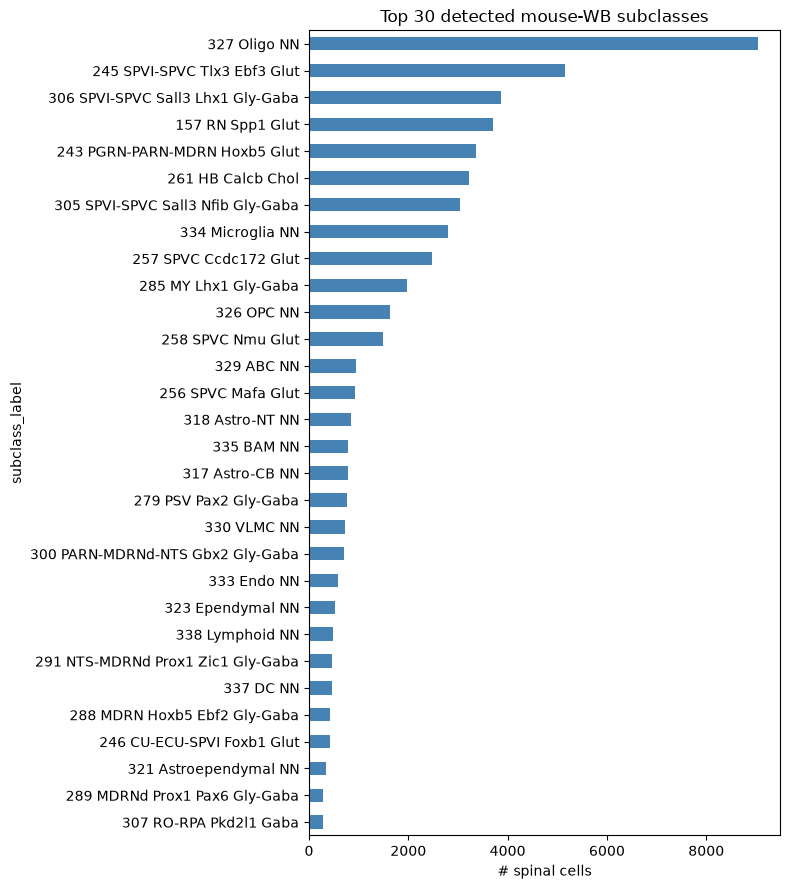

289 distinct mouse-WB subclasses detected.


In [8]:
counts = mapping_df[WB_SUBCLASS_LEVEL].value_counts()
fig, ax = plt.subplots(figsize=(8, 9))
counts.head(30)[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('# spinal cells'); ax.set_title('Top 30 detected mouse-WB subclasses')
plt.tight_layout(); plt.show()
print(f"{(counts > 0).sum()} distinct mouse-WB subclasses detected.")

### Mapping confidence — and a confidence filter

The per-cell **bootstrapping probability** (0–1) reports how stable each
assignment is across resampled marker sets — a cross-species confidence score.
We **keep only assignments with probability ≥ `MIN_PROB` (= 0.5)** so that the
downstream overlap/reciprocity is built from confident calls, not coin-flips.

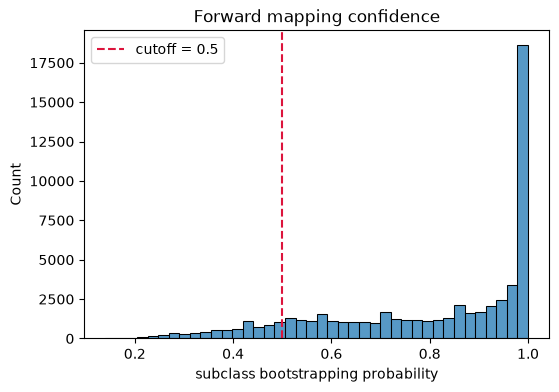

median confidence: 0.88
kept 51706 / 58507 spinal cells (88.4%) at prob >= 0.5


In [9]:
prob_col = f'{WB_SUBCLASS_LEVEL}_prob'
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(mapping_df[prob_col], bins=40, ax=ax)
ax.axvline(MIN_PROB, color='crimson', ls='--', lw=1.5, label=f'cutoff = {MIN_PROB}')
ax.set_xlabel('subclass bootstrapping probability')
ax.set_title('Forward mapping confidence'); ax.legend()
plt.show()
print('median confidence:', round(float(mapping_df[prob_col].median()), 3))

# Keep only confident assignments (bootstrapping probability >= MIN_PROB).
n_before = len(mapping_df)
mapping_df = mapping_df[mapping_df[prob_col] >= MIN_PROB].copy()
print(f'kept {len(mapping_df)} / {n_before} spinal cells '
      f'({len(mapping_df) / n_before:.1%}) at prob >= {MIN_PROB}')

### Forward summary by spinal subclass

For each of **our** spinal subclasses, which mouse-WB subclass do its cells most
often map to? This is the per-row "forward best hit".

In [10]:
fwd_by_sub = mio.summarize_forward_by_query_level(
    mapping_df, qobs, QUERY_SUBCLASS, WB_SUBCLASS_LEVEL)
fwd_by_sub

,top_wb_subclass,top_frac,n_cells
Subclass_V2,,,
Glut-D,245 SPVI-SPVC Tlx3 Ebf3 Glut,0.377586,5898
GABA-D,306 SPVI-SPVC Sall3 Lhx1 Gly-Gaba,0.526902,4758
Glut-V,243 PGRN-PARN-MDRN Hoxb5 Glut,0.446449,3548
Glut-M,245 SPVI-SPVC Tlx3 Ebf3 Glut,0.482447,2763
GABA-V,285 MY Lhx1 Gly-Gaba,0.274446,2751
GABA-M,306 SPVI-SPVC Sall3 Lhx1 Gly-Gaba,0.276990,1834
Oligo,327 Oligo NN,0.732765,1407
Myeloid,334 Microglia NN,0.600000,1375
vMN,261 HB Calcb Chol,0.814423,1040


## 3. Reverse — which mouse-WB subclasses resemble a spinal type?

Now the other direction. We built a **new** `cell_type_mapper` reference from our
**Session-1 (V2)** spinal-cord taxonomy (`Class_V2 → Subclass_V2 → Group_V2`) and
mapped each mouse-WB subclass's mean expression onto it. Building the reference
from our own V2 taxonomy (rather than an external consensus atlas) means the
reverse labels are in the **same vocabulary** as the forward `Subclass_V2` /
`Group_V2` — so the two directions are directly comparable at both levels. The
result tells us, for every mouse subclass, the spinal **Subclass / Group** it most
resembles.

In [11]:
reverse_df = mio.load_mapping_results(
    REVERSE_JSON, levels=['Class', 'Subclass', 'Group'])
reverse_df.index.name = 'mouse_wb_subclass'
print(reverse_df.shape[0], 'mouse-WB subclasses mapped onto the spinal cord')
reverse_df[['Class', 'Subclass', 'Group']].head(10)

338 mouse-WB subclasses mapped onto the spinal cord


,Class,Subclass,Group
mouse_wb_subclass,,,
001 CLA-EPd-CTX Car3 Glut,Glut,Glut-M,Sp5 POU4F1 NMS Glut
002 IT EP-CLA Glut,Glut,Glut-V,Sp5L-8 RELN GDA Glut
003 L5/6 IT TPE-ENT Glut,Glut,Glut-V,Sp10 RNF220 Glut
004 L6 IT CTX Glut,Glut,Glut-V,Sp10 RNF220 Glut
005 L5 IT CTX Glut,Glut,Glut-M,Sp5 POU4F1 NMS Glut
006 L4/5 IT CTX Glut,Glut,Glut-M,Sp5 POU4F1 NMS Glut
007 L2/3 IT CTX Glut,Glut,Glut-M,Sp5 POU4F1 NMS Glut
008 L2/3 IT ENT Glut,Glut,Glut-V,Sp5L-8 RELN GDA Glut
009 L2/3 IT PIR-ENTl Glut,Glut,Glut-M,Sp1-5Lx PHOX2A BCL11A Glut


Which spinal **Subclasses** do the mouse-WB subclasses pile onto? Broad
mouse types collapse onto a few spinal "hub" groups, but the **Subclass** level
(Glut-D/M/V, GABA-D/M/V …) is shared between the two taxonomies and is where the
reciprocal signal is cleanest.

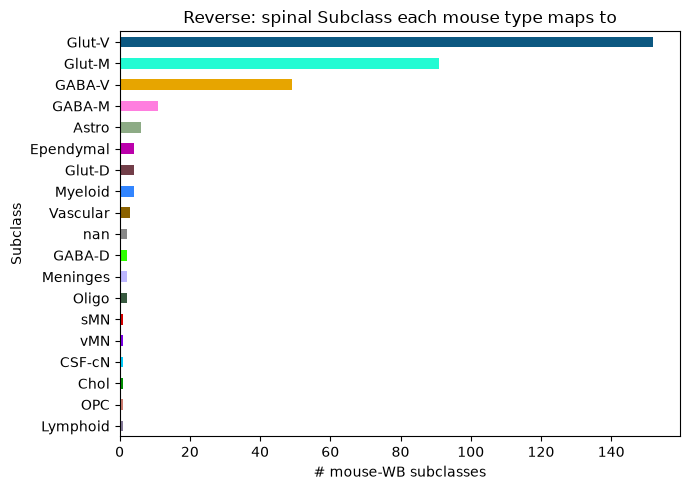

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
vc = reverse_df['Subclass'].value_counts()[::-1]
vc.plot.barh(ax=ax, color=[SUBCLASS_PAL.get(s, '#888888') for s in vc.index])
ax.set_xlabel('# mouse-WB subclasses'); ax.set_title('Reverse: spinal Subclass each mouse type maps to')
plt.tight_layout(); plt.show()

## 4. Reciprocal best hits

A mouse-WB subclass is **reciprocal** when the two directions agree on the spinal
**Subclass**: the spinal cells that map to it (forward) are the same subclass that
it maps back to (reverse). `processing/04` computed this; we load and inspect it.

Agreement alone isn't enough, though: a mouse subclass that only a handful of
spinal cells map to can match by luck. So each pair is graded by `overlap` — the
fraction of those spinal cells that vote for the modal subclass (forward purity) —
and by its **Wilson lower bound** `overlap_lb`, which discounts low-`n` votes
exactly as in §4b. A pair is **reciprocal** only when both directions agree **and**
`overlap_lb ≥ OVERLAP_MIN` (= 0.50).

Watch the dorsal-horn story emerge: brainstem **`SPVI-SPVC`** (spinal-trigeminal)
excitatory `Tlx3` types are reciprocal with our dorsal **`Glut-D`** subclass —
the whole-brain analogue of the spinal dorsal horn.

In [13]:
recip = pd.read_csv(RECIPROCAL_CSV, index_col=0)
n_rec = int(recip['reciprocal'].sum())
print(f"{n_rec} of {len(recip)} detected mouse-WB subclasses are reciprocal "
      f"(agree both ways AND overlap_lb >= {OVERLAP_MIN}).")
recip_true = recip[recip['reciprocal']].sort_values('n_spc_cells', ascending=False)
recip_true.head(20)[['n_spc_cells', 'fwd_spc_subclass', 'overlap', 'overlap_lb',
                     'rev_spc_subclass', 'rev_spc_group']]

48 of 194 detected mouse-WB subclasses are reciprocal (agree both ways AND overlap_lb >= 0.5).


,n_spc_cells,fwd_spc_subclass,overlap,overlap_lb,rev_spc_subclass,rev_spc_group
subclass_label,,,,,,
245 SPVI-SPVC Tlx3 Ebf3 Glut,4167,Glut-D,0.5568,0.5416,Glut-D,Sp1-3 DSCAML1 FBXL7 Glut
306 SPVI-SPVC Sall3 Lhx1 Gly-Gaba,3197,GABA-D,0.7967,0.7824,GABA-D,Sp4L RORB NRGN GABA-Gly
305 SPVI-SPVC Sall3 Nfib Gly-Gaba,2538,GABA-D,0.6844,0.6660,GABA-D,Sp1-4M ZIC1 GABA-Gly
257 SPVC Ccdc172 Glut,2132,Glut-D,0.9981,0.9952,Glut-D,Sp2o NMUR2 Glut
285 MY Lhx1 Gly-Gaba,1487,GABA-V,0.5380,0.5126,GABA-V,Sp5-8 DMRT3 GABA-Gly
327 Oligo NN,1106,Oligo,0.9322,0.9158,Oligo,NN OPALIN Oligo
258 SPVC Nmu Glut,1094,Glut-D,0.9991,0.9948,Glut-D,Sp2i NMU TAC3 Glut
334 Microglia NN,1024,Myeloid,0.9102,0.8911,Myeloid,NN AIF1 Microglia
256 SPVC Mafa Glut,744,Glut-D,0.9153,0.8931,Glut-D,Sp4L MAF Glut


### Reciprocal hits for the dorsal horn (`Glut-D`)

Filter to the mouse-WB subclasses that are reciprocal with our **dorsal
excitatory** spinal subclass. These are the brain regions whose excitatory
neurons most resemble spinal dorsal-horn neurons.

In [14]:
dorsal = recip_true[recip_true['fwd_spc_subclass'].str.contains('Glut-D')]
print('Mouse-WB subclasses reciprocal with spinal Glut-D (dorsal horn):')
dorsal[['n_spc_cells', 'fwd_spc_subclass', 'overlap', 'overlap_lb',
        'rev_spc_subclass', 'rev_spc_group']]

Mouse-WB subclasses reciprocal with spinal Glut-D (dorsal horn):


,n_spc_cells,fwd_spc_subclass,overlap,overlap_lb,rev_spc_subclass,rev_spc_group
subclass_label,,,,,,
245 SPVI-SPVC Tlx3 Ebf3 Glut,4167,Glut-D,0.5568,0.5416,Glut-D,Sp1-3 DSCAML1 FBXL7 Glut
257 SPVC Ccdc172 Glut,2132,Glut-D,0.9981,0.9952,Glut-D,Sp2o NMUR2 Glut
258 SPVC Nmu Glut,1094,Glut-D,0.9991,0.9948,Glut-D,Sp2i NMU TAC3 Glut
256 SPVC Mafa Glut,744,Glut-D,0.9153,0.8931,Glut-D,Sp4L MAF Glut


## 4b. *How* reciprocal? Grading pairs by the overlap coefficient

§4a graded each mouse subclass by how *purely* its spinal cells vote for one
subclass. Here we take a complementary, **symmetric** view: the **overlap
coefficient** (Szymkiewicz–Simpson) between the two cell sets. For a spinal
subclass `S` (its cells = set `A`) and a mouse-WB subclass `M` (cells assigned to
`M` = set `B`):

$$\mathrm{OC}(S, M) = \frac{|A \cap B|}{\min(|A|, |B|)}$$

`OC = 1` means one set sits entirely inside the other — a clean, exclusive
correspondence; `OC ≈ 0` means they barely co-occur.

**The catch:** OC saturates at 1.0 on tiny samples. If only a handful of spinal
nuclei map to a mouse-WB subclass `M` and they happen to share a label, `OC = 1`
even though it rests on almost no evidence. To stop those low-`n` flukes from
counting, we don't gate on the raw OC — we gate on its **Wilson score lower
confidence bound** (`overlap_lb`), treating OC as a proportion estimated from
`n = min(|A|, |B|)` cells:

$$\mathrm{LB} = \frac{\hat p + \tfrac{z^2}{2n} - z\sqrt{\hat p(1-\hat p)/n + z^2/4n^2}}{1 + z^2/n}$$

This shrinks small-`n` overlaps toward 0 (an `OC = 1` from 1 cell → ≈ 0.21, from
6 cells → ≈ 0.61) while leaving well-supported overlaps almost untouched. We call
a pair **reciprocal** when *both* directions name the same spinal subclass **and**
`overlap_lb ≥ OVERLAP_MIN` ( = 0.50, with `z = 1.96` ≈ 95%). `processing/07`
precomputed this.

In [15]:
sub_ov = pd.read_csv(SUBCLASS_OVERLAP_CSV, index_col=0)
n_rec = int(sub_ov['reciprocal'].sum())
print(f"{n_rec} of {len(sub_ov)} mouse-WB subclasses are reciprocal "
      f"(agree both ways AND overlap_lb >= {OVERLAP_MIN}).")
# Note how overlap_lb pulls down the low-n_spc_cells rows relative to raw overlap.
sub_ov.sort_values('overlap_lb', ascending=False).head(15)[
    ['n_spc_cells', 'fwd_spc_subclass', 'overlap', 'overlap_lb',
     'rev_spc_subclass', 'reciprocal']]

49 of 194 mouse-WB subclasses are reciprocal (agree both ways AND overlap_lb >= 0.5).


,n_spc_cells,fwd_spc_subclass,overlap,overlap_lb,rev_spc_subclass,reciprocal
subclass_label,,,,,,
257 SPVC Ccdc172 Glut,2132,Glut-D,0.998124,0.995186,Glut-D,True
258 SPVC Nmu Glut,1094,Glut-D,0.999086,0.994840,Glut-D,True
261 HB Calcb Chol,2276,sMN,0.995767,0.989167,sMN,True
323 Ependymal NN,363,Ependymal,0.994490,0.980136,Ependymal,True
331 Peri NN,186,Vascular,0.994624,0.970179,Vascular,True
318 Astro-NT NN,336,Astro,0.988095,0.969794,Astro,True
289 MDRNd Prox1 Pax6 Gly-Gaba,258,GABA-V,0.984496,0.960821,GABA-V,True
338 Lymphoid NN,326,Lymphoid,0.978528,0.956348,Lymphoid,True
307 RO-RPA Pkd2l1 Gaba,248,CSF-cN,0.979839,0.953680,CSF-cN,True


### Reciprocal mapping heatmap (subclass level)

Recompute the full overlap-coefficient matrix (spinal subclasses × detected
mouse-WB subclasses) and show it for the **reciprocal** mouse-WB subclasses,
grouped by the spinal subclass they reciprocate with. The bright block down each
spinal column is its set of whole-brain counterparts — read off, for example, the
`Glut-D` column to see every brainstem dorsal-horn-like subclass.

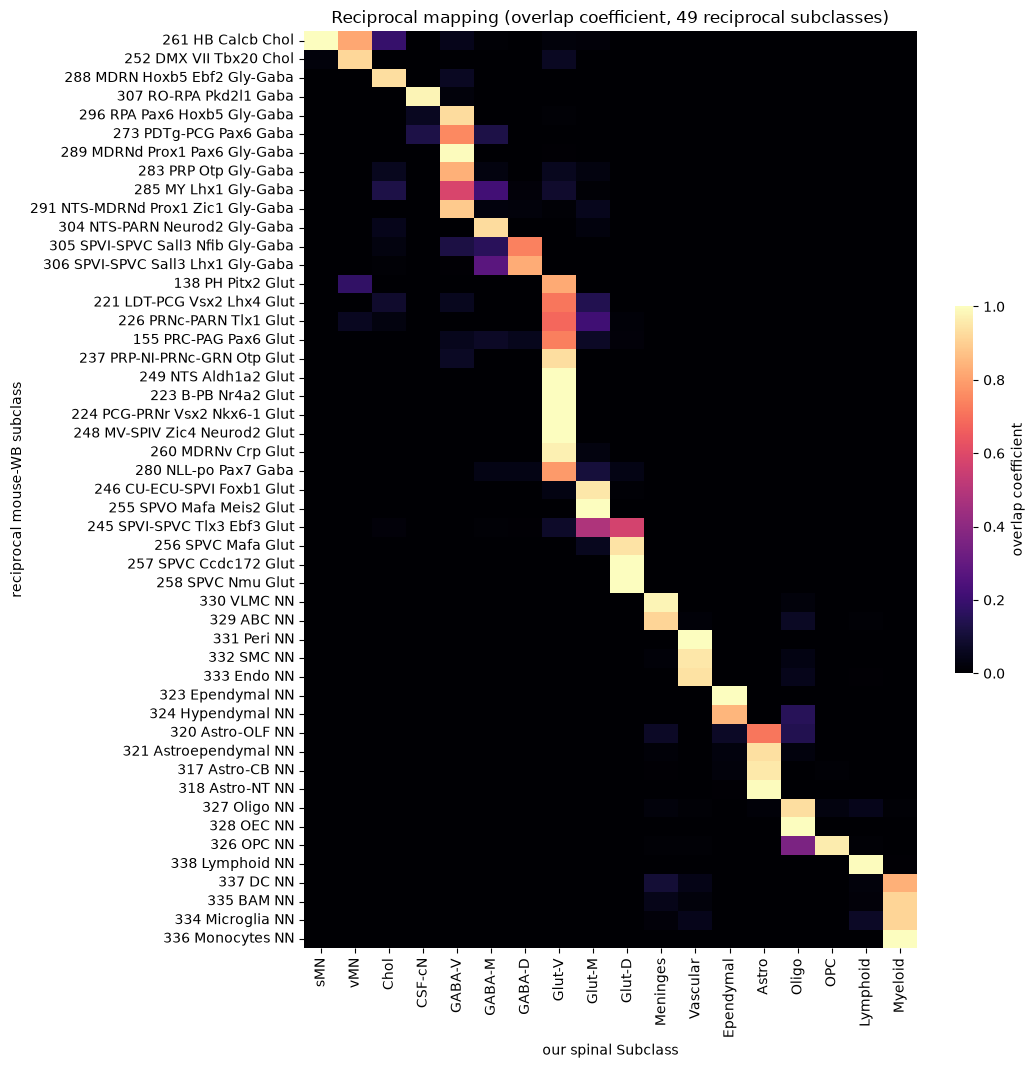

In [16]:
def diagonal_row_order(M):
    """Row-label order that maximizes diagonality for a FIXED column order:
    sort rows by their intensity-weighted mean column (barycenter), so each
    row's bright cells march down the diagonal."""
    A = M.to_numpy(float); w = A.sum(1); cols = np.arange(A.shape[1])
    bary = np.where(w > 0, (A * cols).sum(1) / np.where(w > 0, w, 1.0), A.shape[1])
    keys = np.lexsort((-A.max(1), A.argmax(1), bary))   # primary = barycenter
    return M.index[keys]

oc = mio.overlap_coefficient_matrix(mapping_df, qobs, QUERY_SUBCLASS,
                                    WB_SUBCLASS_LEVEL)            # spinal × WB
rec_wb = [m for m in sub_ov.index[sub_ov['reciprocal']] if m in oc.columns]
# Spinal columns: only subclasses with a reciprocal partner (kept in order).
spc_cols = [c for c in oc.index if c in set(sub_ov.loc[rec_wb, 'fwd_spc_subclass'])]
H = oc.loc[spc_cols, rec_wb].T                                   # WB(rows) × spinal(cols)
H = H.loc[diagonal_row_order(H)]    # reorder ABC rows for diagonality; columns fixed

fig, ax = plt.subplots(figsize=(1.0 + 0.55 * len(spc_cols), max(6, 0.22 * len(H))))
sns.heatmap(H, cmap='magma', vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'overlap coefficient', 'shrink': 0.4})
ax.set_xlabel('our spinal Subclass'); ax.set_ylabel('reciprocal mouse-WB subclass')
ax.set_title(f'Reciprocal mapping (overlap coefficient, {len(H)} reciprocal subclasses)')
plt.tight_layout(); plt.show()

## 4c. Finer grain: reciprocal **supertypes**

Subclass is fairly coarse. Using the subsampled mouse-WB snRNA dataset
(`wb_subsampled_ABC.h5ad`, kept small enough to ship to you — the full atlas is
224 GB) we built **supertype** mean profiles and ran the reverse arm again at
supertype resolution. Here we step the *spinal* side down a level too: a
supertype is **reciprocal** when the spinal **`Group_V2`** it maps back to matches
the forward best-matching `Group_V2` of its parent mouse-WB subclass, inheriting
the same support-discounted `overlap_lb ≥ OVERLAP_MIN` gate from §4b. So the
mapping is **ABC subclass ↔ `Subclass_V2`** (§4b) but **ABC supertype ↔
`Group_V2`** here — finer on both sides.

In [17]:
st_recip = pd.read_csv(SUPERTYPE_RECIP_CSV, index_col=0)
n_st = int(st_recip['reciprocal'].sum())
print(f"{n_st} of {len(st_recip)} mouse-WB supertypes are reciprocal.")
# How many reciprocal supertypes fall under each spinal Group_V2?
by_spc = (st_recip[st_recip['reciprocal']]
          .groupby('fwd_spc_group').size().sort_values(ascending=False))
print('\nReciprocal supertypes per spinal Group_V2:'); print(by_spc)
st_recip[st_recip['reciprocal']].sort_values('overlap_lb', ascending=False).head(15)[
    ['parent_wb_subclass', 'fwd_spc_group', 'rev_spc_group', 'overlap', 'overlap_lb']]

37 of 697 mouse-WB supertypes are reciprocal.

Reciprocal supertypes per spinal Group_V2:
fwd_spc_group
NN FAM81 Ependymal              3
NN THEMIS Lymphocyte            3
NN OPALIN Oligo                 2
Sp6Mc PITX2 Glut                2
LSp1,3 NPY ECEL1 GABA-Gly       2
NN SLC7A10 GM-Astro             2
NN SLC38A11 Peri-SMC            2
NN PDGFRA OPC                   2
aMN-ff CHODL Chol               2
Sp5-8 DMRT3 GABA-Gly            2
NN DPP4 Monocyte                1
NN MPZ Schwann                  1
NN DCN ABC                      1
NN AIF1 Microglia               1
CSF-cN PKD2L1 GABA-Gly          1
NN CLDN5 Endo                   1
Sp GATA3 GABA-Gly               1
Sp4L MAF Glut                   1
Sp4 MAF RORB Glut               1
Sp2o NMUR2 Glut                 1
Sp5-6 NR4A2 DLK1 Glut           1
Sp5L-8 RELN GDA Glut            1
Sp5L-8 LHX4 DNAH11 Glut         1
Sp5M-6M,10 NFIB SP8 GABA-Gly    1
Sp5M SLC17A7 Glut               1
dtype: int64


,parent_wb_subclass,fwd_spc_group,rev_spc_group,overlap,overlap_lb
supertype,,,,,
1020 SPVC Ccdc172 Glut_1,257 SPVC Ccdc172 Glut,Sp2o NMUR2 Glut,Sp2o NMUR2 Glut,1.000000,0.990487
1184 MOL NN_4,327 Oligo NN,NN OPALIN Oligo,NN OPALIN Oligo,1.000000,0.990487
1183 MFOL NN_3,327 Oligo NN,NN OPALIN Oligo,NN OPALIN Oligo,1.000000,0.990487
1026 HB Calcb Chol_2,261 HB Calcb Chol,aMN-ff CHODL Chol,aMN-ff CHODL Chol,1.000000,0.983780
1027 HB Calcb Chol_3,261 HB Calcb Chol,aMN-ff CHODL Chol,aMN-ff CHODL Chol,1.000000,0.983780
1175 Ependymal NN_1,323 Ependymal NN,NN FAM81 Ependymal,NN FAM81 Ependymal,0.994490,0.980136
1176 Ependymal NN_2,323 Ependymal NN,NN FAM81 Ependymal,NN FAM81 Ependymal,0.994490,0.980136
1199 ILC NN_2,338 Lymphoid NN,NN THEMIS Lymphocyte,NN THEMIS Lymphocyte,0.978528,0.956348
1200 NK cells NN_3,338 Lymphoid NN,NN THEMIS Lymphocyte,NN THEMIS Lymphocyte,0.978528,0.956348


### Supertype mapping confidence — and the same 0.5 filter

Each mouse-WB **supertype** mean was mapped onto our V2 spinal reference; the
`Group_V2` **bootstrapping probability** grades how stable each supertype→Group
call is. Exactly as for the forward arm (§2) we keep only supertypes whose call
clears `MIN_PROB` (= 0.5) — so **both** directions of the mapping are confidence-
filtered at the same threshold.

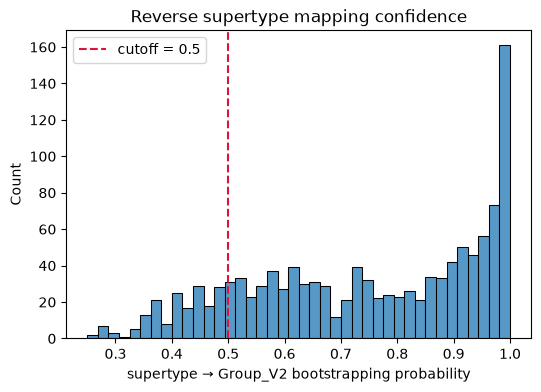

kept 1024 / 1201 supertypes at prob >= 0.5; median = 0.84


In [18]:
st_rev = mio.load_mapping_results(SUPERTYPE_REVERSE_JSON,
                                  levels=['Class', 'Subclass', 'Group'])
gp = 'Group_prob'
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(st_rev[gp], bins=40, ax=ax)
ax.axvline(MIN_PROB, color='crimson', ls='--', lw=1.5, label=f'cutoff = {MIN_PROB}')
ax.set_xlabel('supertype → Group_V2 bootstrapping probability')
ax.set_title('Reverse supertype mapping confidence'); ax.legend()
plt.show()
n_before = len(st_rev)
st_rev = st_rev[st_rev[gp] >= MIN_PROB]
print(f'kept {len(st_rev)} / {n_before} supertypes at prob >= {MIN_PROB}; '
      f'median = {round(float(st_rev[gp].median()), 3)}')

### Reciprocal mapping heatmap (supertype level)

The supertype analogue of the §4b heatmap. Rows are the **reciprocal mouse-WB
supertypes** that also pass the confidence filter; columns are the spinal
**`Group_V2`** they reciprocate with (kept in a fixed order). Each cell is shaded
by the supertype→Group bootstrapping probability, and — exactly as in §4b — the
ABC supertype **rows are reordered to drive the bright cells onto the diagonal**
while the spinal Group columns stay put. Each spinal-Group column then shows the
block of whole-brain supertypes that map to it.

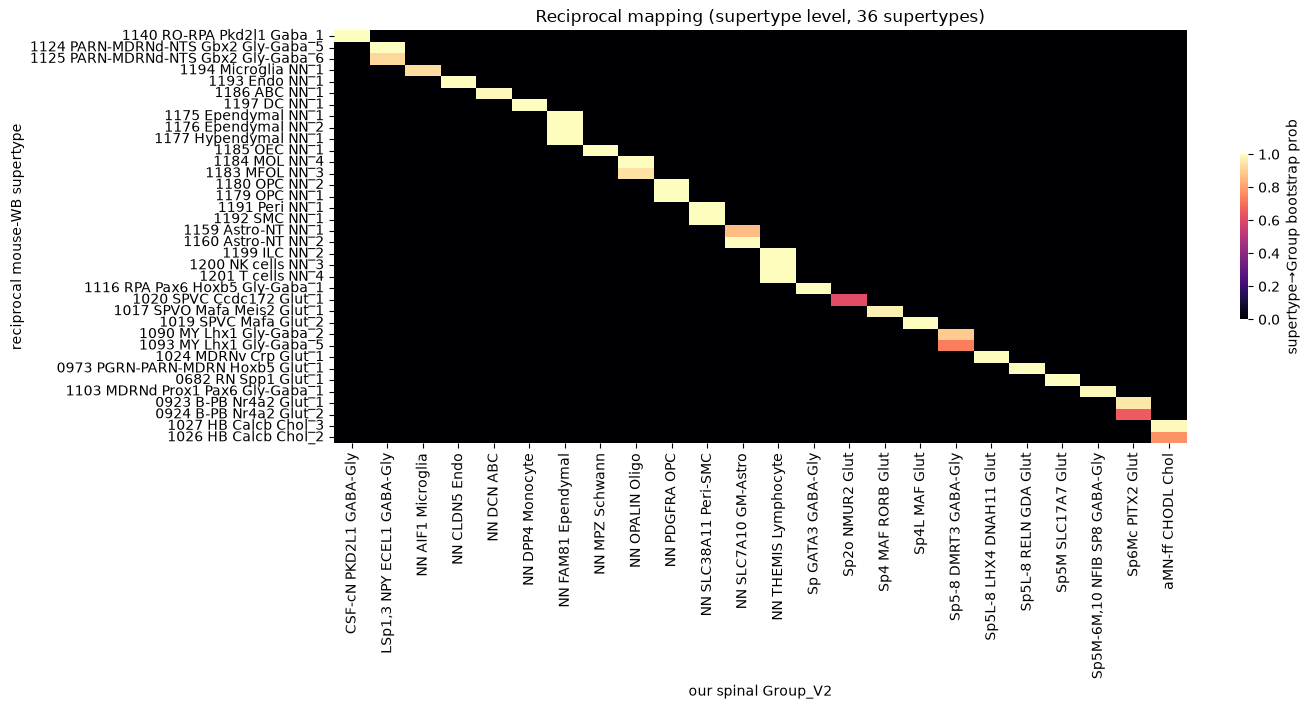

In [19]:
st_rt = st_recip[st_recip['reciprocal']].copy()
st_rt = st_rt.loc[st_rt.index.intersection(st_rev.index)]      # confident only
spc_groups = sorted(set(st_rt['fwd_spc_group']))               # spinal cols, fixed order
M = pd.DataFrame(0.0, index=st_rt.index, columns=spc_groups)
for t, r in st_rt.iterrows():
    g = r['fwd_spc_group']                                     # == rev group (reciprocal)
    if g in M.columns:
        M.at[t, g] = float(st_rev.at[t, 'Group_prob'])
M = M.loc[diagonal_row_order(M)]    # reorder ABC supertype rows for diagonality

fig, ax = plt.subplots(figsize=(1.0 + 0.55 * len(spc_groups), max(6, 0.20 * len(M))))
sns.heatmap(M, cmap='magma', vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'supertype→Group bootstrap prob', 'shrink': 0.4})
ax.set_xlabel('our spinal Group_V2'); ax.set_ylabel('reciprocal mouse-WB supertype')
ax.set_title(f'Reciprocal mapping (supertype level, {len(M)} supertypes)')
plt.tight_layout(); plt.show()

## 5. Where do the detected types live? (forward coverage)

For every mouse-WB subclass we score how strongly the spinal query "detected" it
(`representation_score` = min(n_spinal_cells / FULL_N, 1)), then paint that score
onto each atlas cell. **Green = detected** by the spinal cord, **red = not** —
i.e. brain regions whose cell types resemble spinal cells light up green.

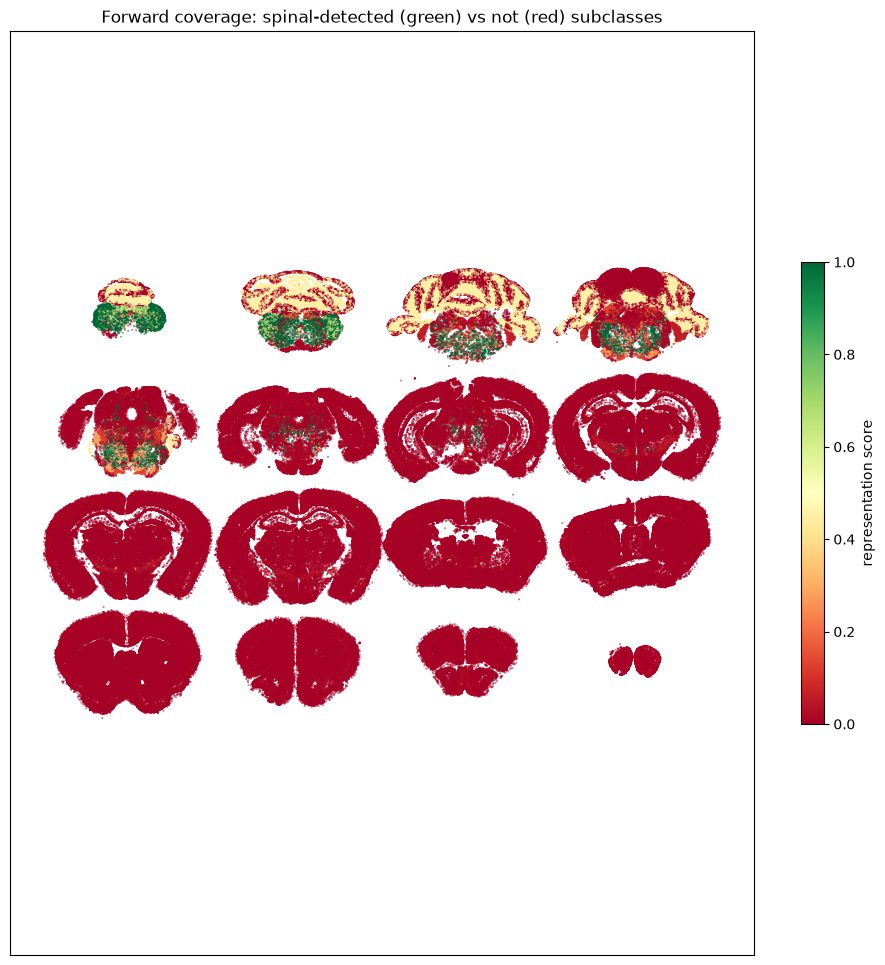

In [20]:
FULL_N = 500   # spinal cells at which a subclass counts as fully represented
rep_df = mio.representation_table(
    detected_counts=mapping_df[WB_SUBCLASS_LEVEL].value_counts(),
    reference_subclasses=adata_atlas.obs[ATLAS_SUBCLASS].cat.categories,
    full_n=FULL_N, specificity=specificity)
mio.attach_representation_to_spatial(adata_atlas, rep_df, subclass_key=ATLAS_SUBCLASS)

# Drop ubiquitous non-neuronal ("… NN") types so neuronal structure is visible.
neurons = adata_atlas[~adata_atlas.obs[ATLAS_SUBCLASS].str.contains(' NN$', regex=True)]
o = neurons.obs
fig, ax, sct = plot_section(o['x'], o['y'], val=o['representation_score'].values,
                            cmap='RdYlGn', s=0.3,
                            title='Forward coverage: spinal-detected (green) vs not (red) subclasses')
plt.colorbar(sct, ax=ax, shrink=0.5, label='representation score'); plt.show()

## 6. Where do the **reciprocal** subclasses live? (neurons only)

Now the payoff: paint each atlas cell by the spinal **Subclass** it **reciprocates**
with (agreeing both ways with support-discounted overlap `overlap_lb ≥ OVERLAP_MIN`):
`Glut-D` dorsal, `Glut-V` ventral, `GABA-*` inhibitory, … Non-reciprocal cells are
greyed out. We restrict the canvas to **neuronal** atlas cells, since the non-neuronal
`NN` types blanket the whole brain and wash out the picture. Expect the
**hindbrain / medulla** and the **spinal-trigeminal** territory to light up.

reciprocal subclasses: 49 | painted 13040 neuronal cells (1.9% of neurons)


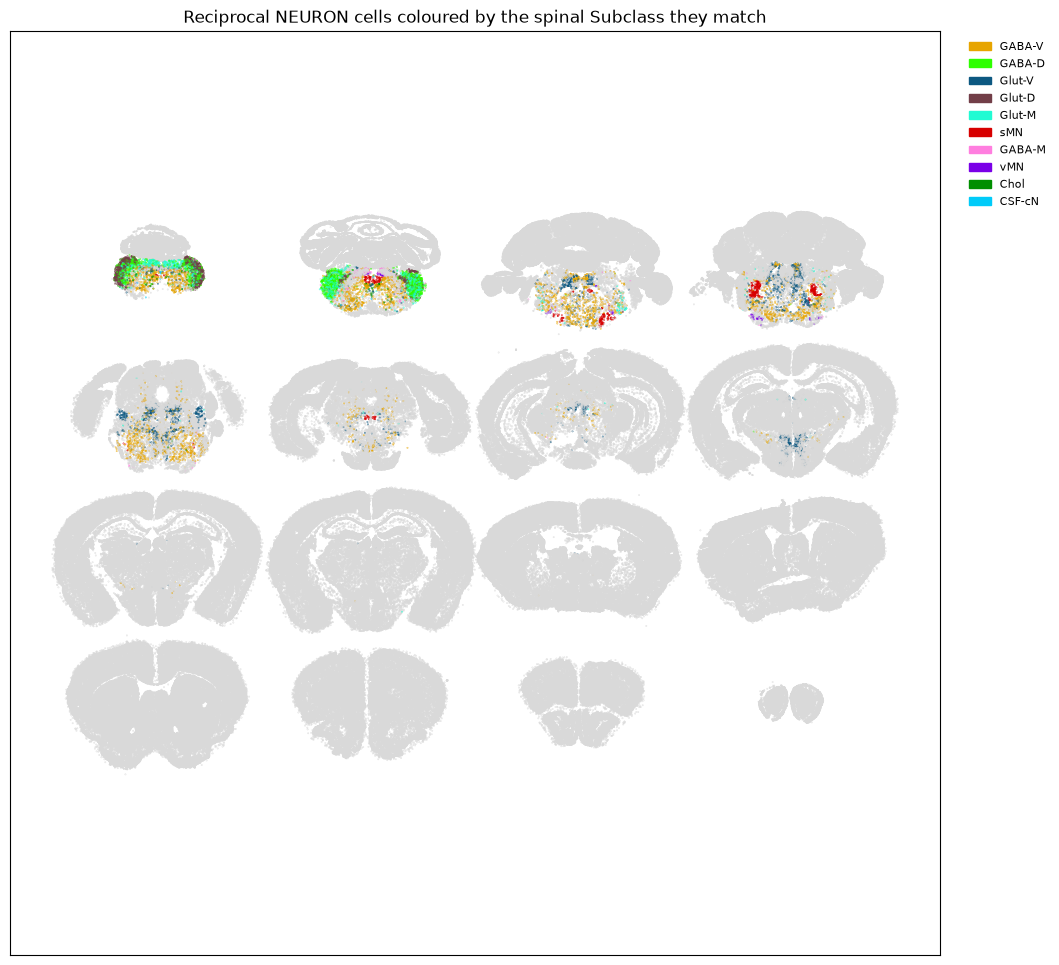

In [21]:
recip_set = set(sub_ov.index[sub_ov['reciprocal']])
sub_map = sub_ov.loc[sub_ov['reciprocal'], 'fwd_spc_subclass'].to_dict()
# Full-atlas reciprocal flag for the CCF region tabulation in §7.
adata_atlas.obs['is_reciprocal'] = (
    adata_atlas.obs[ATLAS_SUBCLASS].astype(str).isin(recip_set))

# Neurons-only canvas (the 'NN' non-neurons are everywhere).
neurons = adata_atlas[~adata_atlas.obs[ATLAS_SUBCLASS].str.contains(' NN$', regex=True)]
o = neurons.obs.copy()
o['recip_spc_subclass'] = o[ATLAS_SUBCLASS].astype(str).map(sub_map)
print('reciprocal subclasses:', len(recip_set), '| painted',
      int(o['recip_spc_subclass'].notna().sum()), 'neuronal cells',
      f"({o['recip_spc_subclass'].notna().mean():.1%} of neurons)")

cats = o['recip_spc_subclass'].dropna().value_counts().head(10).index.tolist()
# Canonical Subclass_V2 colours from the spinal-cord h5ad (grey fallback).
palette = {c: SUBCLASS_PAL.get(c, '#dddddd') for c in cats}
GREY = '#d9d9d9'
colors = [palette[v] if (isinstance(v, str) and v in palette) else GREY
          for v in o['recip_spc_subclass']]
fig, ax, _ = plot_section(o['x'], o['y'], cc=colors, s=0.3,
                          title='Reciprocal NEURON cells coloured by the spinal Subclass they match')
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=palette[c], label=c) for c in cats],
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=False)
plt.show()

## 6b. Reciprocal **neuron** supertypes in space

Finally, the finest grain — but **neurons only**. Because reciprocity was resolved
per supertype against **`Group_V2`** (§4c), each reciprocal supertype carries a
specific spinal Group. We **drop the non-neuronal matches** (the `NN …` spinal
groups — oligodendrocytes, microglia, astrocytes, …), since those cell types blanket
the whole brain and wash out the picture. What remains are the mapped **neuron**
supertypes, coloured by the spinal **`Group_V2`** they reciprocate with, on a
neurons-only canvas — so specific dorsal/ventral neuronal territories stand out.

18 reciprocal NEURON supertypes; painted 2898 neuronal cells (0.4% of neurons)


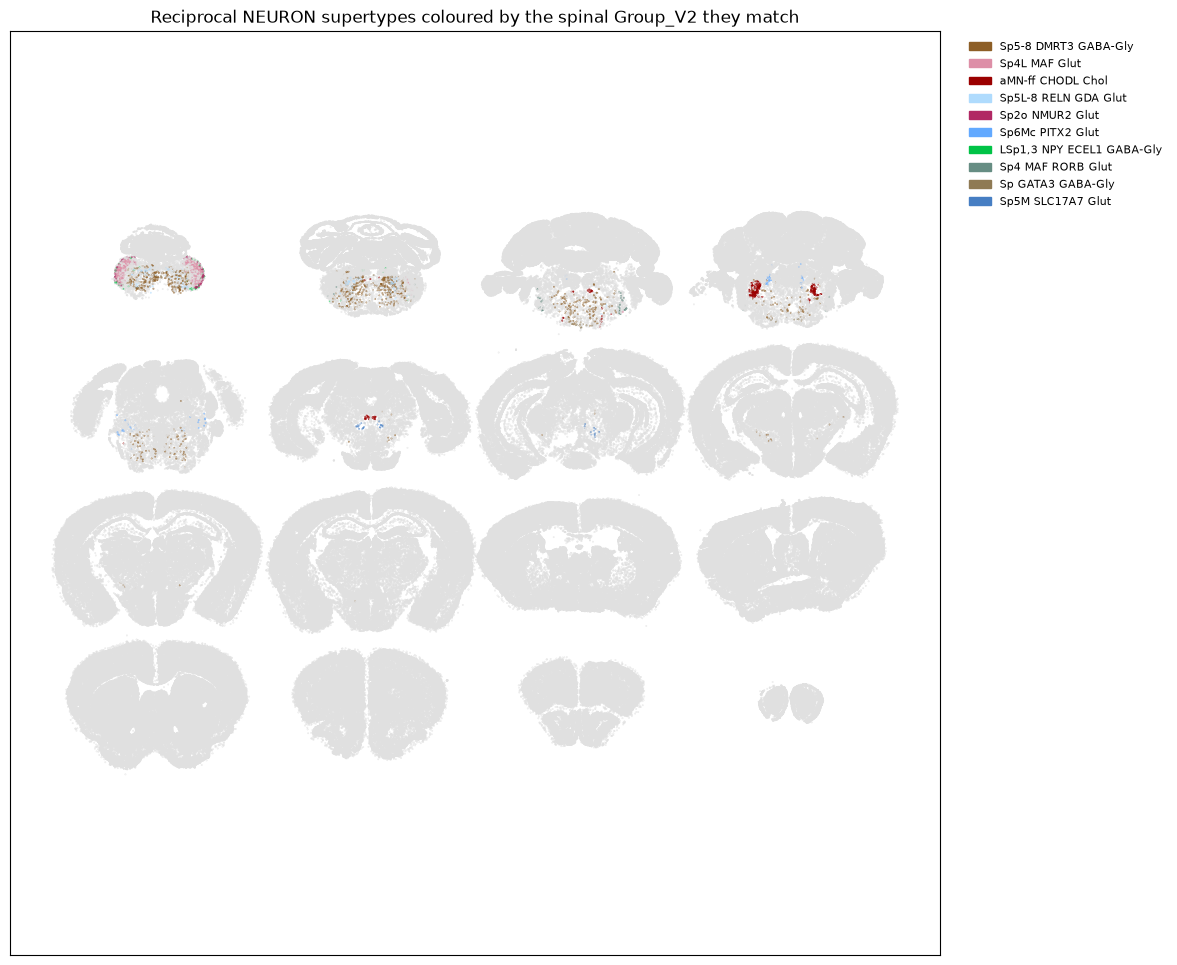

In [22]:
# Reciprocal supertypes -> spinal Group_V2, NEURONS ONLY (drop 'NN ...' groups).
recip_super = {t: g for t, g in zip(st_recip.index[st_recip['reciprocal']],
                                    st_recip.loc[st_recip['reciprocal'], 'fwd_spc_group'])
               if not str(g).startswith('NN ')}
# Restrict the canvas to neuronal atlas cells too (the 'NN' non-neurons are everywhere).
neurons = adata_atlas[~adata_atlas.obs[ATLAS_SUBCLASS].str.contains(' NN$', regex=True)]
o = neurons.obs.copy()
o['is_recip_supertype'] = o[ATLAS_SUPERTYPE].astype(str).isin(recip_super)
o['recip_super_spc'] = o[ATLAS_SUPERTYPE].astype(str).map(recip_super)
print(f"{len(recip_super)} reciprocal NEURON supertypes;",
      'painted', int(o['is_recip_supertype'].sum()), 'neuronal cells',
      f"({o['is_recip_supertype'].mean():.1%} of neurons)")

cats2 = o['recip_super_spc'].dropna().value_counts().head(10).index.tolist()
# Canonical Group_V2 colours from the spinal-cord h5ad (grey fallback).
pal2 = {c: GROUP_PAL.get(c, '#dddddd') for c in cats2}
colors2 = [pal2[v] if (isinstance(v, str) and v in pal2) else '#e0e0e0'
           for v in o['recip_super_spc']]
fig, ax, _ = plot_section(o['x'], o['y'], cc=colors2, s=0.3,
                          title='Reciprocal NEURON supertypes coloured by the spinal Group_V2 they match')
ax.legend(handles=[mpatches.Patch(color=pal2[c], label=c) for c in cats2],
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=False)
plt.show()

## 7. Which brain regions are the reciprocal types in?

Cross-tabulate the reciprocal cells against their **CCF region** (anatomical
parcellation) to name the structures most spinal-cord-like in transcriptome.

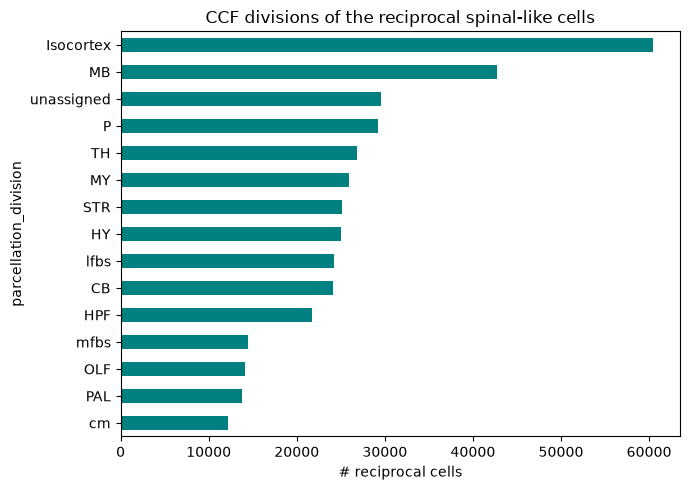

parcellation_division
Isocortex     60486
MB            42697
unassigned    29600
P             29222
TH            26819
MY            25983
STR           25140
HY            24970
lfbs          24283
CB            24092
HPF           21754
mfbs          14443
OLF           14118
PAL           13838
cm            12235
Name: count, dtype: int64

In [23]:
recip_cells = adata_atlas.obs[adata_atlas.obs['is_reciprocal']]
region = (recip_cells['parcellation_division'].astype(str)
          .value_counts().head(15))
fig, ax = plt.subplots(figsize=(7, 5))
region[::-1].plot.barh(ax=ax, color='teal')
ax.set_xlabel('# reciprocal cells'); ax.set_title('CCF divisions of the reciprocal spinal-like cells')
plt.tight_layout(); plt.show()
region

## 8. Exercise & discussion — functional interpretation

You now have a reciprocal map between the spinal cord and the whole brain, and a
picture of where the spinal-like types live. Discuss / explore:

1. **Dorsal horn analogue.** Section 3 showed `SPVI-SPVC Tlx3 … Glut` is
   reciprocal with spinal `Glut-D`. `Tlx3` is the canonical **dorsal-horn
   excitatory** selector gene. Which CCF division did these cells fall in (§7)?
   Why does the *spinal-trigeminal nucleus* resemble the dorsal horn?
2. **Ventral vs dorsal.** Compare where `Glut-D` vs `Glut-V` reciprocal cells sit
   in §6. Does the dorsal/ventral spinal axis have a whole-brain counterpart?
3. **Coverage gaps.** In §5, which neuronal regions stayed **red** (no spinal
   match)? Those are mouse-WB types with *no* spinal counterpart — sanity-check a
   few (forebrain? cerebellum?).
4. **Confidence.** Re-make the §2 confidence histogram split by `Class_V2`
   (`adata_q.obs`). Do non-neuronal cells map more confidently than neurons?

> **Scaling up.** Here the reverse arm used 338 subclass *means*. The full
> 4,042,976-cell `AIT21 → spinal cord` mapping (≈3.6 h) is bundled at
> `/data/hmba_xs_v1/mouse_wb/AIT21.all.freeze.230815_humanorthos_ABC_MAPPING/` —
> per-cell reciprocity at the same resolution.

---
*Reciprocal mapping built with [cell_type_mapper](https://github.com/AllenInstitute/cell_type_mapper)
(MapMyCells). Forward reference: AIT21 mouse whole-brain subclasses. Reverse
reference: our Session-1 (V2) spinal-cord taxonomy. Spatial atlas: ABC MERFISH
`C57BL6J-638850`.*